# Análise de Somadores Quânticos: Escalabilidade e Resiliência a Ruídos
Este notebook unifica a arquitetura dos somadores RCA, AQFT e QCLA, extraindo métricas de profundidade assintótica e taxa de sucesso sob diferentes modelos de erro. Os gráficos gerados estão formatados para exportação em alta resolução (300 DPI), prontos para inclusão em artigos científicos.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from qiskit import transpile
from qiskit.circuit.quantumcircuit import QuantumCircuit
from qiskit.circuit import Gate
from qiskit.circuit.library import CXGate, CCXGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeKyiv, FakeAachen

# --- Configuração de Gráficos para Artigos Científicos (Paper-ready) ---
plt.rcParams.update({
    'font.family': 'serif',        # Fonte serifada padrão acadêmico
    'font.size': 12,               # Tamanho base
    'axes.labelsize': 14,          # Tamanho dos eixos
    'axes.titlesize': 14,          # Tamanho do título
    'legend.fontsize': 11,         # Tamanho da legenda
    'xtick.labelsize': 11,         # Tick marks X
    'ytick.labelsize': 11,         # Tick marks Y
    'figure.dpi': 300,             # Alta resolução para visualização
    'savefig.dpi': 300,            # Alta resolução para exportação
    'savefig.bbox': 'tight',       # Evita corte das bordas ao salvar
    'lines.linewidth': 2.5,        # Linhas mais visíveis
    'lines.markersize': 8          # Marcadores definidos
})

# --- Modelos de Ruído ---
fake_kyiv = FakeKyiv()
fake_aachen = FakeAachen()
hw_noise_kyiv = NoiseModel.from_backend(fake_kyiv)
hw_noise_aachen = NoiseModel.from_backend(fake_aachen)

custom_depol = NoiseModel()
custom_depol.add_all_qubit_quantum_error(depolarizing_error(0.01, 2), ['cx', 'cp'])

noise_envs = {
    "Ideal": None,
    "Depolarizing (p=0.01)": custom_depol,
    "Hardware (Kyiv)": hw_noise_kyiv,
    "Hardware (Aachen)": hw_noise_aachen
}

In [ ]:
# ==========================================
# GATES AUXILIARES E RIPPLE CARRY ADDER
# ==========================================
class Carry(Gate):
    def __init__(self):
        super().__init__(name="Carry", num_qubits=4, params=[])
        qc = QuantumCircuit(4, name=self.name)
        c_in, a, b, c_out = 0, 1, 2, 3
        qc.append(CCXGate(), [a, b, c_out])
        qc.append(CXGate(),  [a, b])
        qc.append(CCXGate(), [c_in, b, c_out])
        self.definition = qc

class Sum(Gate):
    def __init__(self):
        super().__init__(name="Sum", num_qubits=3, params=[])
        qc = QuantumCircuit(3, name=self.name)
        c_in, a, b = 0, 1, 2
        qc.cx(a, b)
        qc.cx(c_in, b)
        self.definition = qc

class RippleCarryAdder(Gate):
    def __init__(self, n: int):
        num_q = 3 * n + 1
        super().__init__(name="RCA", num_qubits=num_q, params=[])
        carry = Carry(); sum_gate = Sum(); i_carry = carry.inverse()
        qc = QuantumCircuit(num_q, name=self.name)
        for i in range(0, num_q - 3, 3): qc.append(carry, [i, i + 1, i + 2, i + 3])
        qc.cx(num_q - 3, num_q - 2)
        qc.append(sum_gate, [num_q - 4, num_q - 3, num_q - 2])
        for j in range(num_q - 4, 0, -3):
            qc.append(i_carry,  [j - 3, j - 2, j - 1, j])
            qc.append(sum_gate, [j - 3, j - 2, j - 1])
        self.definition = qc

# ==========================================
# QFT E AQFT ADDER (Com Carry-Out n+1)
# ==========================================
class QFT(Gate):
    def __init__(self, n: int, do_swaps: bool = True):
        self.do_swaps = do_swaps
        super().__init__(name="QFT", num_qubits=n, params=[])
        qc = QuantumCircuit(n, name=self.name)
        for j in range(n - 1, -1, -1):
            qc.h(j)
            for k in range(j - 1, -1, -1):
                lam = np.pi / (2.0 ** (j - k))
                qc.cp(lam, k, j)
        if self.do_swaps:
            for i in range(n // 2): qc.swap(i, n - i - 1)
        self.definition = qc

class AQFT(Gate):
    def __init__(self, n: int, do_swap: bool = True):
        self.do_swap = do_swap
        super().__init__(name="AQFT", num_qubits=n, params=[])
        qc = QuantumCircuit(n, name=self.name)
        m = int(np.ceil(np.log2(n))) if n > 0 else 0
        for j in range(n - 1, -1, -1):
            qc.h(j)
            for k in range(j - 1, max(j - m, -1), -1):
                lam = np.pi / (2.0 ** (j - k))
                qc.cp(lam, k, j)
        if self.do_swap:
            for i in range(n // 2): qc.swap(i, n - i - 1)
        self.definition = qc

class QFTDraperAdder(Gate):
    def __init__(self, n: int):
        num_q = 2 * n + 1
        super().__init__(name="QFTDraper", num_qubits=num_q, params=[])
        qc = QuantumCircuit(num_q, name=self.name)
        qr_a = list(range(n))
        qr_b = list(range(n, 2 * n + 1))
        
        qc.append(QFT(n + 1, do_swaps=True), qr_b)
        for k in range(n + 1):
            lam = np.pi / (2 ** k)
            for j in range(n):
                target = n - j - k
                if target >= 0:
                    qc.cp(lam, qr_a[j], qr_b[target])
        qc.append(QFT(n + 1, do_swaps=True).inverse(), qr_b)
        self.definition = qc

class AQFTDraperAdder(Gate):
    def __init__(self, n: int):
        num_q = 2 * n + 1
        super().__init__(name="AQFTDraper", num_qubits=num_q, params=[])
        qc = QuantumCircuit(num_q, name=self.name)
        reg_a = list(range(n))
        reg_b = list(range(n, 2 * n + 1))
        
        qc.append(AQFT(n + 1, do_swap=True), reg_b)
        for k in range(n + 1):
            lam = np.pi / (2 ** k)
            for j in range(n):
                target = n - j - k
                if target >= 0:
                    qc.cp(lam, reg_a[j], reg_b[target])
        qc.append(AQFT(n + 1, do_swap=True).inverse(), reg_b)
        self.definition = qc


def _ptree(n):
    idx, k = {}, 0
    logn = int(np.floor(np.log2(n))) if n >= 1 else 0
    for t in range(1, logn + 1):
        for m in range(1, n // (2 ** t)):
            idx[(t, m)] = k; k += 1
    return idx, k, logn

def _carry_ccx(n, cmap, pmap, ancmap):
    Pidx, _, logn = _ptree(n)
    P = lambda t, m: pmap[m] if t == 0 else ancmap[(t, m)]
    g = []
    for t in range(1, logn + 1):
        for m in range(1, n // (2 ** t)): g.append((P(t - 1, 2 * m), P(t - 1, 2 * m + 1), P(t, m)))
    for t in range(1, logn + 1):
        for m in range(0, n // (2 ** t)):
            g.append((P(t - 1, 2 * m + 1), cmap[2 ** t * m + 2 ** (t - 1) - 1], cmap[2 ** t * m + 2 ** t - 1]))
    if n >= 2:
        for t in range(int(np.floor(np.log2((2 * n) / 3.0))), 0, -1):
            for m in range(1, (n - 2 ** (t - 1)) // (2 ** t) + 1):
                g.append((P(t - 1, 2 * m), cmap[2 ** t * m - 1], cmap[2 ** t * m + 2 ** (t - 1) - 1]))
    for t in range(logn, 0, -1):
        for m in range(1, n // (2 ** t)): g.append((P(t - 1, 2 * m), P(t - 1, 2 * m + 1), P(t, m)))
    return g

class CarryLookaheadAdder(Gate):
    def __init__(self, n: int):
        Pidx, pk, logn = _ptree(n)
        num_q = 4 * n + 1 + pk
        super().__init__(name="QCLA", num_qubits=num_q, params=[])
        qc = QuantumCircuit(num_q, name=self.name)
        a = list(range(n)); b = list(range(n, 2 * n))
        s = list(range(2 * n, 3 * n + 1)); c = list(range(3 * n + 1, 4 * n + 1))
        panc = list(range(4 * n + 1, 4 * n + 1 + pk))
        ancmap = {k: panc[v] for k, v in Pidx.items()} if pk > 0 else {}
        cg = _carry_ccx(n, c, b, ancmap)
        
        for i in range(n): qc.ccx(a[i], b[i], c[i])
        for i in range(n): qc.cx(a[i], b[i])
        for x1, x2, tg in cg: qc.ccx(x1, x2, tg)
        for i in range(n):
            qc.cx(b[i], s[i])
            if i >= 1: qc.cx(c[i - 1], s[i])
        qc.cx(c[n - 1], s[n])
        for x1, x2, tg in reversed(cg): qc.ccx(x1, x2, tg)
        for i in range(n): qc.cx(a[i], b[i])
        for i in range(n): qc.ccx(a[i], b[i], c[i])
        self.definition = qc

def setup_evaluation_circuit(adder_gate, n, x, y):
    total_qubits = adder_gate.num_qubits
    qc = QuantumCircuit(total_qubits, n + 1)
    
    if adder_gate.name == "RCA":
        for i in range(n):
            if (x >> i) & 1: qc.x(3 * i + 1)
            if (y >> i) & 1: qc.x(3 * i + 2)
    else:
        for i in range(n):
            if (x >> i) & 1: qc.x(i)          
            if (y >> i) & 1: qc.x(n + i)      
            
    qc.append(adder_gate, range(total_qubits))
    
    if adder_gate.name == "RCA":
        for i in range(n): qc.measure(3 * i + 2, i)
        qc.measure(3 * n, n) 
    elif adder_gate.name in ["AQFTDraper", "QFTDraper"]:
        for i in range(n + 1): qc.measure(n + i, i)
    elif adder_gate.name == "QCLA":
        for i in range(n + 1): qc.measure(2 * n + i, i)
        
    return qc

Transpilando circuitos para extração de profundidade...
Gráfico salvo como: scalability_depth_en.png


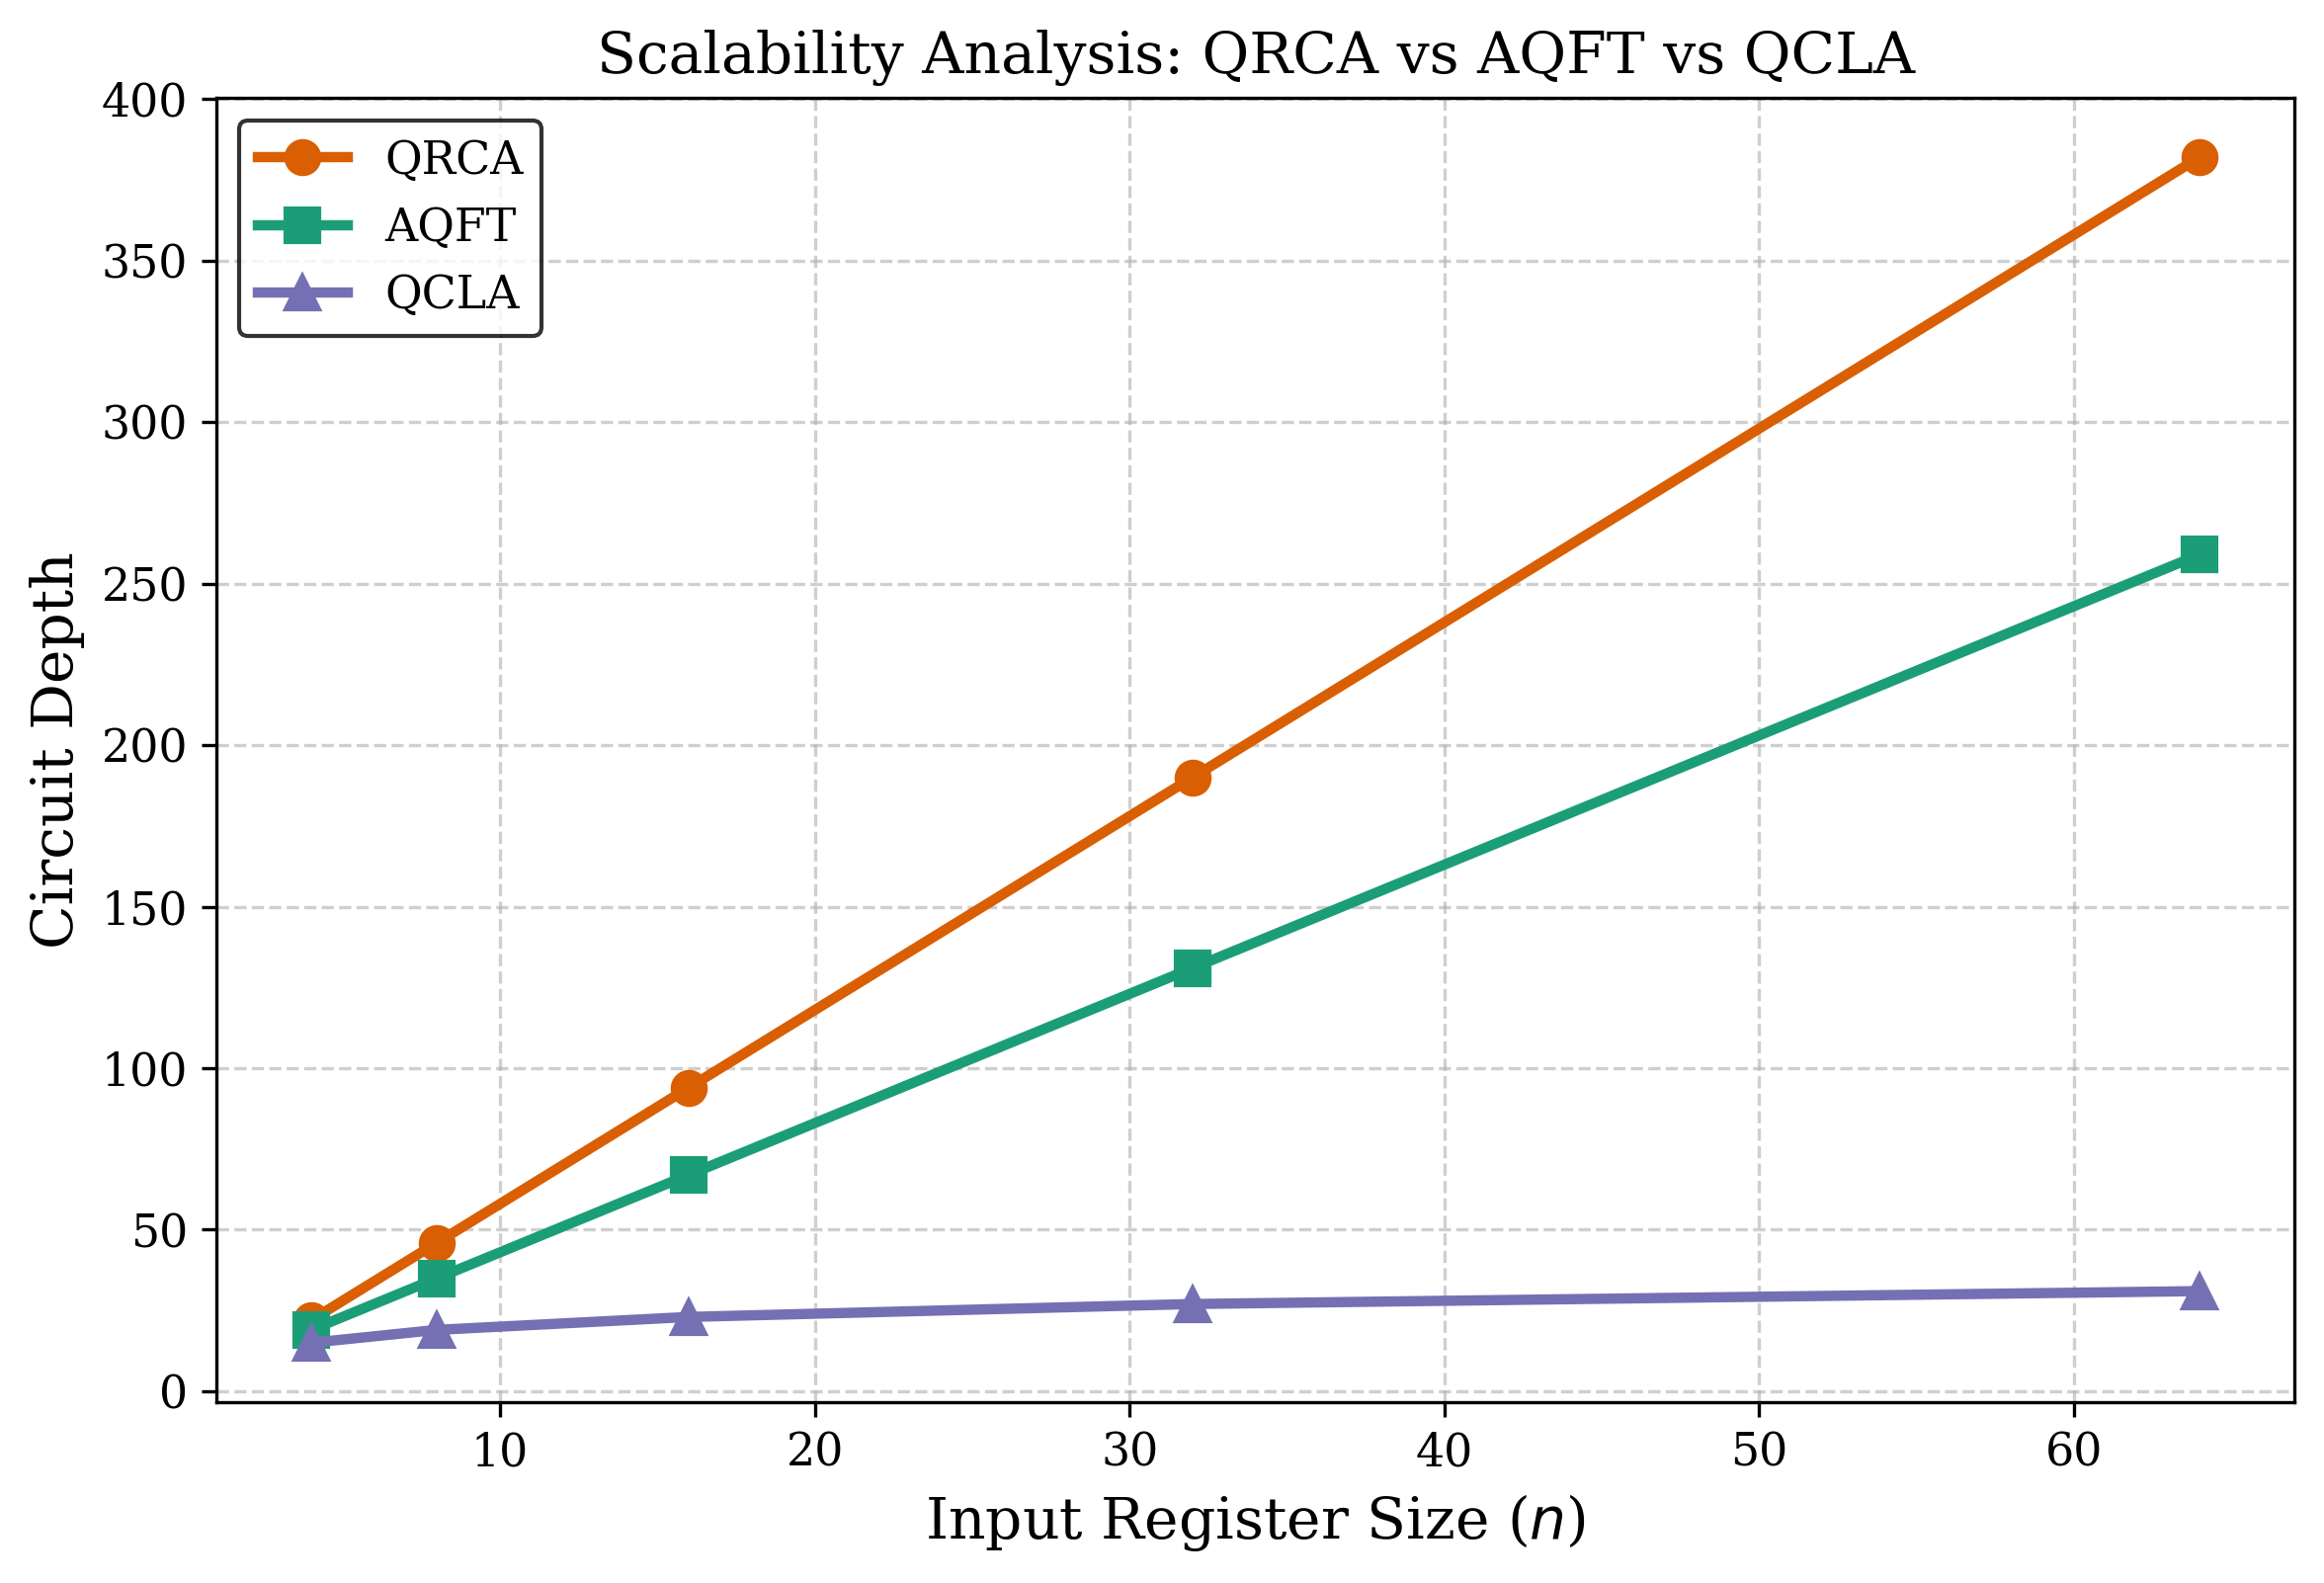

Gráfico salvo como: scalability_depth_pt.png


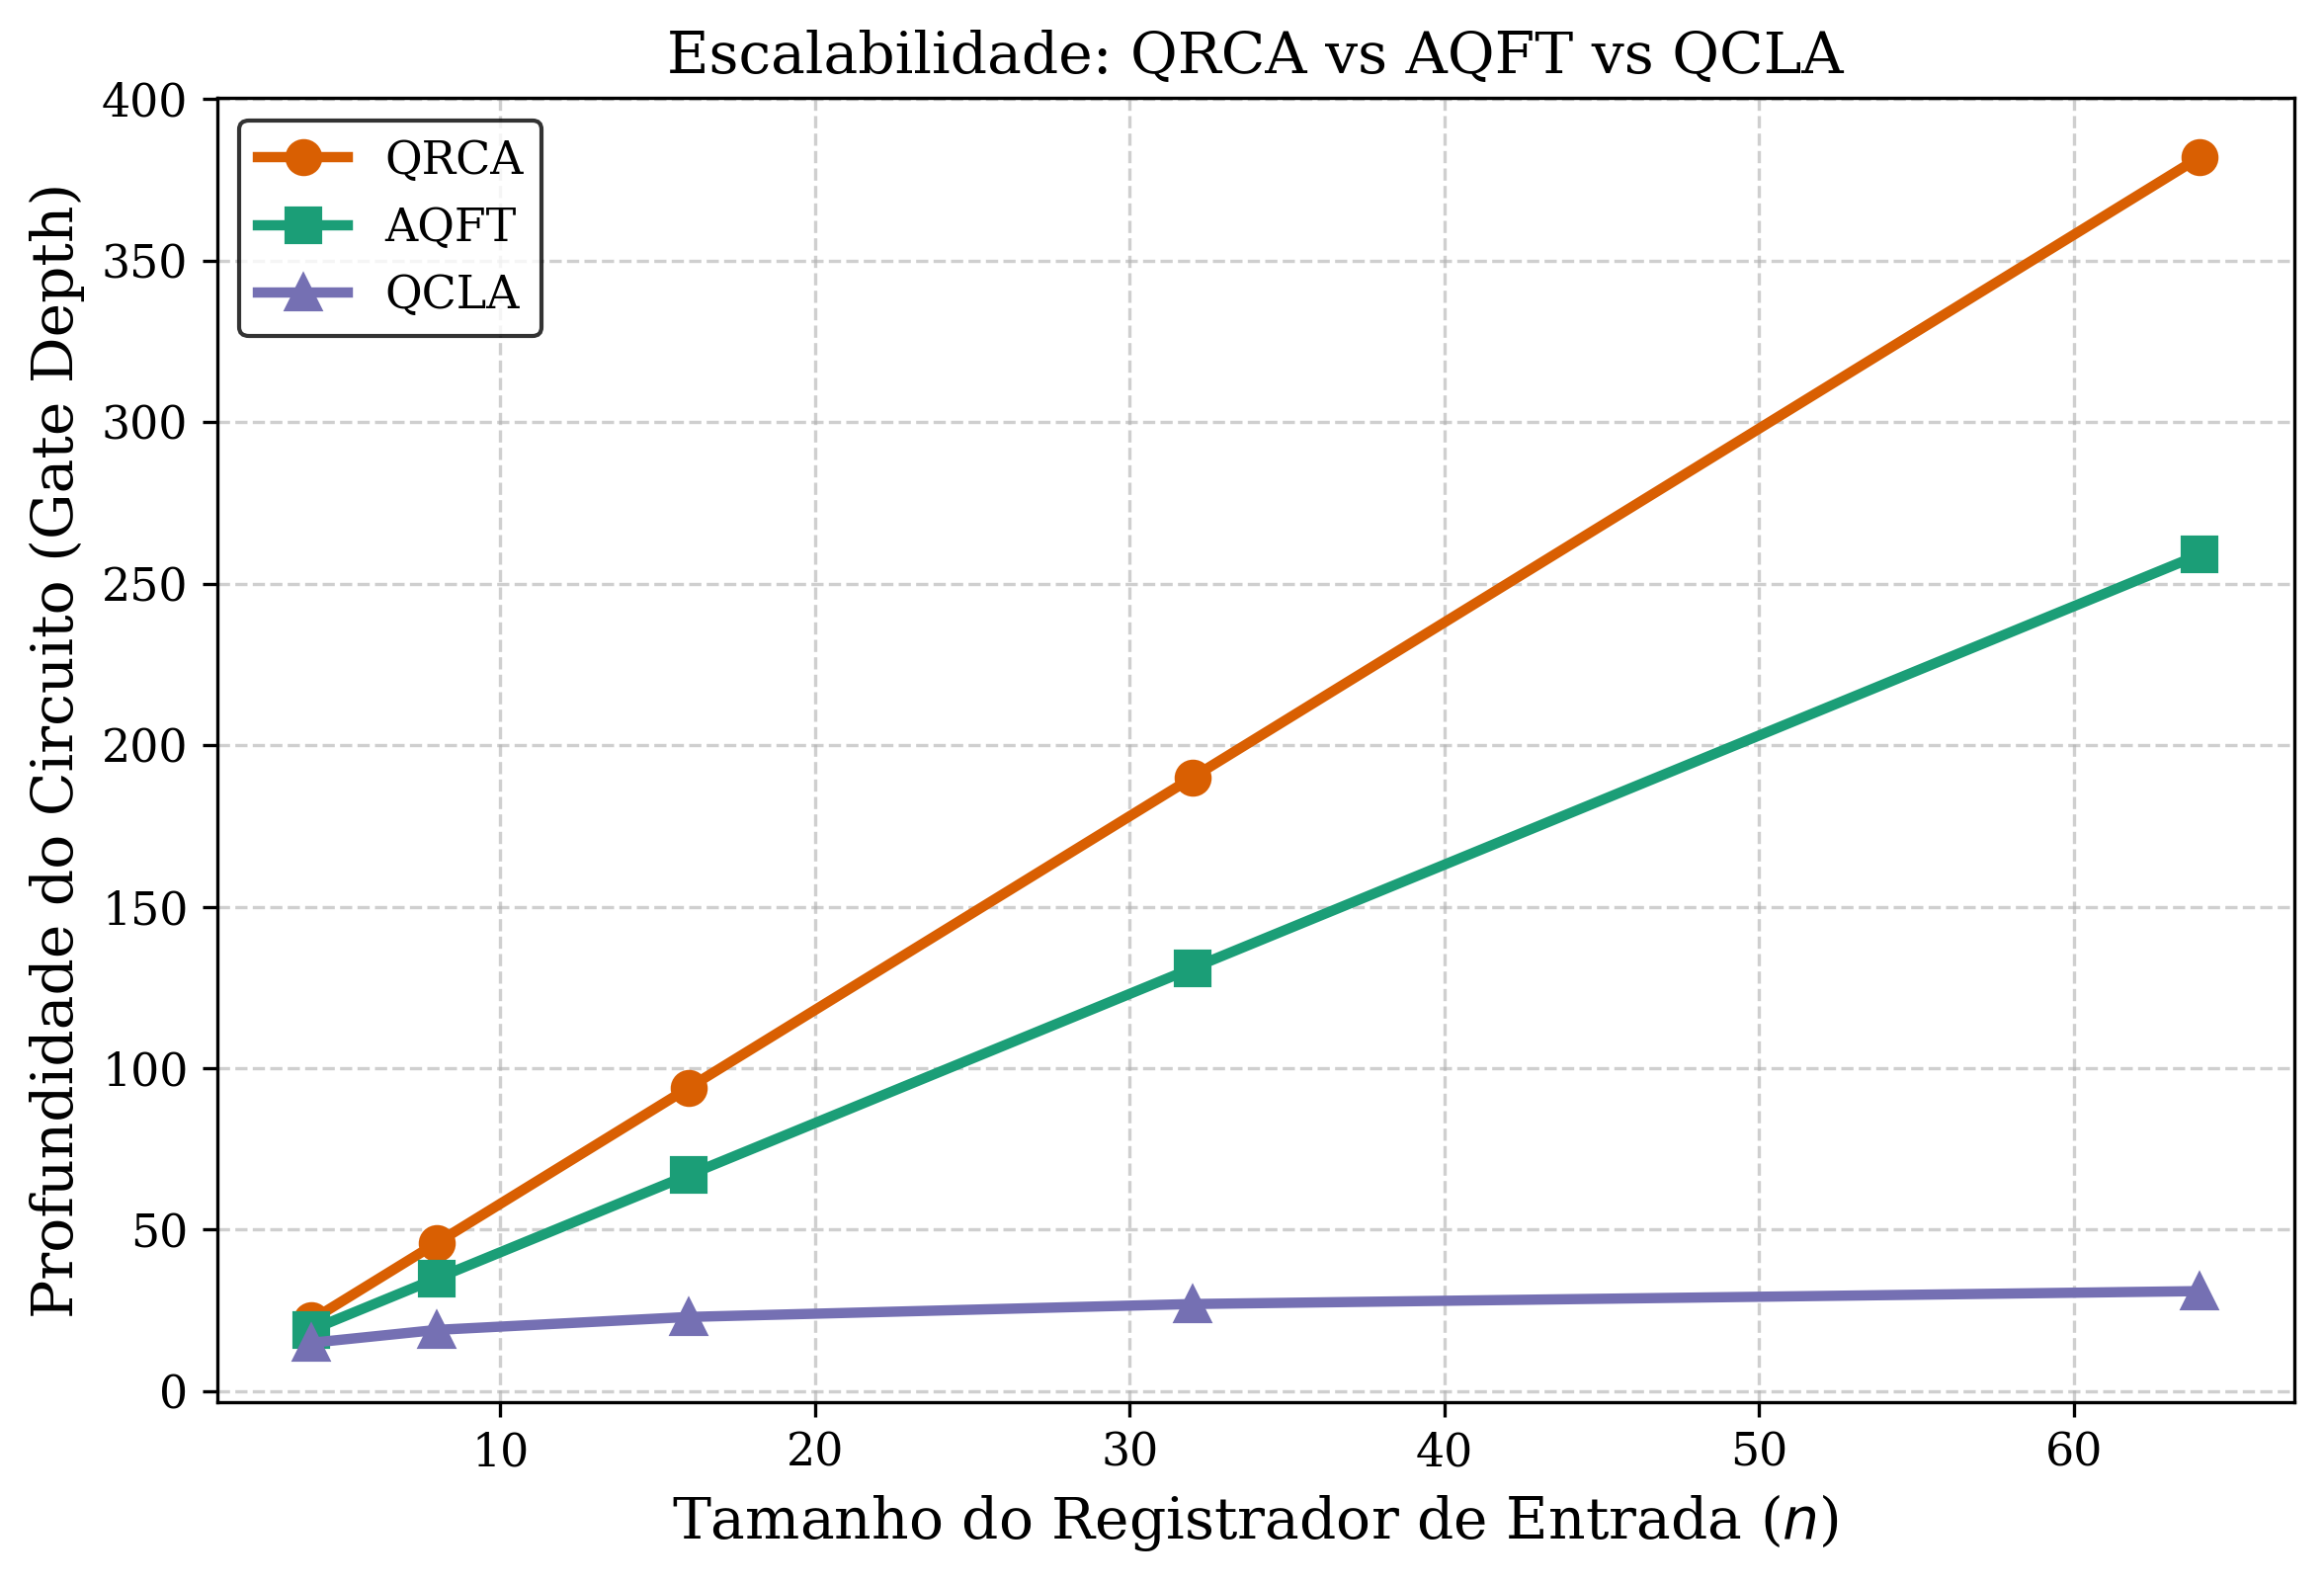

In [ ]:
# 1. Parâmetros de Escala
n_values_depth = [4, 8, 16, 32, 64]
depth_results = {"QRCA": [], "AQFT": [], "QCLA": []}

# 2. Extração
print("Transpilando circuitos para extração de profundidade...")
for n in n_values_depth:
    adders_depth = {
        "QRCA": RippleCarryAdder(n),
        "AQFT": AQFTDraperAdder(n),
        "QCLA": CarryLookaheadAdder(n)
    }
    for name, gate in adders_depth.items():
        qc_depth = QuantumCircuit(gate.num_qubits)
        qc_depth.append(gate, range(gate.num_qubits))
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # Optimization_level=2 melhora a análise de comutatividade
            qc_t = transpile(qc_depth, basis_gates=['u3', 'cx', 'cp', 'ccx'], optimization_level=2)
        
        depth_results[name].append(qc_t.depth())

def plot_scalability(lang='en'):
    plt.figure(figsize=(8, 5.5))
    colors = {'QRCA': '#d95f02', 'AQFT': '#1b9e77', 'QCLA': '#7570b3'}
    markers = {'QRCA': 'o', 'AQFT': 's', 'QCLA': '^'}
    
    for name, depths in depth_results.items():
        plt.plot(n_values_depth, depths, marker=markers[name], color=colors[name], 
                 linewidth=2.5, markersize=8, label=name)

    if lang == 'pt':
        plt.xlabel('Tamanho do Registrador de Entrada ($n$)')
        plt.ylabel('Profundidade do Circuito (Gate Depth)')
        plt.title('Escalabilidade: QRCA vs AQFT vs QCLA')
    else:
        plt.xlabel('Input Register Size ($n$)')
        plt.ylabel('Circuit Depth')
        plt.title('Scalability Analysis: QRCA vs AQFT vs QCLA')

    plt.legend(frameon=True, shadow=False, edgecolor='black')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    filename = f'scalability_depth_{lang}.png'
    plt.savefig(filename)
    print(f"Gráfico salvo como: {filename}")
    plt.show()

# Gerar os gráficos nos dois idiomas
plot_scalability(lang='en')
plot_scalability(lang='pt')